In [0]:
bucket_path = "s3a://sppevribucket/rawdata3"
files = dbutils.fs.ls(bucket_path)
print(len(files))
display(files)

1000


path,name,size,modificationTime
s3a://sppevribucket/rawdata3/H000.json,H000.json,330,1748978406000
s3a://sppevribucket/rawdata3/H001.json,H001.json,322,1748978406000
s3a://sppevribucket/rawdata3/H0010.json,H0010.json,323,1748978407000
s3a://sppevribucket/rawdata3/H00100.json,H00100.json,318,1748978413000
s3a://sppevribucket/rawdata3/H00101.json,H00101.json,321,1748978413000
s3a://sppevribucket/rawdata3/H00102.json,H00102.json,323,1748978413000
s3a://sppevribucket/rawdata3/H00103.json,H00103.json,318,1748978413000
s3a://sppevribucket/rawdata3/H00104.json,H00104.json,325,1748978414000
s3a://sppevribucket/rawdata3/H00105.json,H00105.json,319,1748978414000
s3a://sppevribucket/rawdata3/H00106.json,H00106.json,325,1748978414000


In [0]:
from pyspark.sql.functions import input_file_name, regexp_replace

bucket_path = "s3a://sppevribucket/rawdata3"

# Read files using Auto Loader
df = (spark.readStream
      .format("cloudFiles")
      .option("cloudFiles.format", "json")
      .option("cloudFiles.inferSchema", "true")
      .option("multiline", "true")
      .option("cloudFiles.pathGlobFilter", "H*.json")  
      .option("cloudFiles.schemaLocation", f"{bucket_path}/schema4/")
      .option("cloudFiles.validateOptions", "false")
      .load(bucket_path))
# mode permissive
# Add source file information
df = df.withColumn("file_path", input_file_name())
df = df.withColumn("barcode", regexp_replace(input_file_name(), r".*/|\.json", ""))
display_query = display(df)

# Write to a bronze table (uncomment if needed)
streaming_query = df.writeStream.format("delta").option("checkpointLocation", "s3a://sppevribucket/checkpoints/bronze3").table("bronze_table_WO_explode")


acceptable_image_quality,door_open,door_type,door_visible,location_context,number_of_parcels_visible,parcel_environment,parcel_exposed_to_elements,parcel_visible,pii_in_image,raw_features,resident_visible,_rescued_data,file_path,barcode
false,yes,wooden,yes,suburban,1,backyard,yes,yes,yes,some_raw_features_data,yes,null,s3a://sppevribucket/rawdata3/H000.json,H000
false,no,wooden,no,suburban,4,front door,yes,yes,yes,some_raw_features_data,yes,null,s3a://sppevribucket/rawdata3/H0011.json,H0011
true,yes,glass,yes,suburban,3,backyard,yes,no,yes,some_raw_features_data,yes,null,s3a://sppevribucket/rawdata3/H00109.json,H00109
false,yes,wooden,yes,urban,2,backyard,yes,yes,no,some_raw_features_data,no,null,s3a://sppevribucket/rawdata3/H00104.json,H00104
true,yes,metal,no,suburban,3,front door,no,no,no,some_raw_features_data,no,null,s3a://sppevribucket/rawdata3/H00106.json,H00106
false,no,glass,no,suburban,5,front door,no,no,no,some_raw_features_data,no,null,s3a://sppevribucket/rawdata3/H00111.json,H00111
true,yes,glass,no,suburban,5,garage,yes,yes,yes,some_raw_features_data,no,null,s3a://sppevribucket/rawdata3/H00107.json,H00107
true,yes,metal,yes,suburban,2,porch,yes,yes,yes,some_raw_features_data,no,null,s3a://sppevribucket/rawdata3/H00108.json,H00108
true,no,wooden,no,suburban,1,garage,no,no,yes,some_raw_features_data,yes,null,s3a://sppevribucket/rawdata3/H0010.json,H0010
false,yes,metal,no,rural,0,backyard,yes,no,no,some_raw_features_data,yes,null,s3a://sppevribucket/rawdata3/H00102.json,H00102


# **Clean Up ( one time cell )**

In [0]:

# for query in spark.streams.active:
#     query.stop()
# print("All active streaming queries have been stopped.")

# # Clean up schema, checkpoint, and table
# dbutils.fs.rm(f"{bucket_path}/schema4/", recurse=True)
# dbutils.fs.rm("s3a://sppevribucket/checkpoints/bronze3", recurse=True)
# spark.sql("DROP TABLE IF EXISTS bronze_table_WO_explode")

# # Exit the notebook cell
# dbutils.notebook.exit("Cell execution stopped.")

True

In [0]:
total_count = spark.table("bronze_table_WO_explode").count()
total_count

1000

In [0]:
from pyspark.sql import Row
import random

# Generate dummy data
data = []
statuses = ["pending", "departed", "arrived", "in_transit"]
for i in range(1000):
    barcode = f"H00{i}"
    status = random.choice(statuses)
    quantity = random.randint(1, 10)
    location = f"Location_{random.randint(1, 20)}"
    data.append(Row(barcode=barcode, status=status, quantity=quantity, location=location))

# Create DataFrame
df = spark.createDataFrame(data)

# Save DataFrame as Delta table
df.write.format("delta").mode("overwrite").saveAsTable("silver_parcel_tracking")

# Display DataFrame
display(df)

barcode,status,quantity,location
H000,pending,7,Location_9
H001,departed,3,Location_14
H002,pending,9,Location_5
H003,arrived,3,Location_7
H004,in_transit,9,Location_10
H005,arrived,10,Location_7
H006,departed,5,Location_8
H007,pending,10,Location_10
H008,arrived,6,Location_11
H009,arrived,6,Location_16


In [0]:
import random
from datetime import datetime, timedelta

# Generate dummy data
data = []
for i in range(1000):
    tracking_number = f"T00{i}"
    expected_delivery_date = (datetime.now() + timedelta(days=random.randint(1, 10))).strftime('%Y-%m-%d')
    estimated_arrival_time = (datetime.now() + timedelta(hours=random.randint(1, 24))).strftime('%H:%M:%S')
    barcode = f"H00{i}"
    data.append(Row(tracking_number=tracking_number, expected_delivery_date=expected_delivery_date, estimated_arrival_time=estimated_arrival_time, barcode=barcode))

# Create DataFrame
df = spark.createDataFrame(data)

# Save DataFrame as Delta table
df.write.format("delta").mode("overwrite").saveAsTable("silver_parcel_information")

# Display DataFrame
display(df)

tracking_number,expected_delivery_date,estimated_arrival_time,barcode
T000,2025-06-07,18:36:41,H000
T001,2025-06-12,22:36:41,H001
T002,2025-06-11,11:36:41,H002
T003,2025-06-13,15:36:41,H003
T004,2025-06-06,04:36:41,H004
T005,2025-06-09,00:36:41,H005
T006,2025-06-10,15:36:41,H006
T007,2025-06-09,20:36:41,H007
T008,2025-06-12,12:36:41,H008
T009,2025-06-12,12:36:41,H009


In [0]:
# Load the tables
df_parcel_info = spark.table("silver_parcel_information")
df_parcel_tracking = spark.table("silver_parcel_tracking")
df_bronze_wo_explode = spark.table("bronze_table_WO_explode")

# Perform the join on the barcode field
df_silver_delivery = df_parcel_info.join(df_parcel_tracking, "barcode").join(df_bronze_wo_explode, "barcode")

# Save the result as a new Delta table
df_silver_delivery.write.format("delta").mode("overwrite").saveAsTable("silver_delivery")

# Display the resulting DataFrame
display(df_silver_delivery)

barcode,tracking_number,expected_delivery_date,estimated_arrival_time,status,quantity,location,acceptable_image_quality,door_open,door_type,door_visible,location_context,number_of_parcels_visible,parcel_environment,parcel_exposed_to_elements,parcel_visible,pii_in_image,raw_features,resident_visible,_rescued_data,file_path
H00500,T00500,2025-06-10,19:36:41,departed,9,Location_9,false,yes,wooden,yes,urban,2,backyard,no,yes,yes,some_raw_features_data,yes,null,s3a://sppevribucket/rawdata3/H00500.json
H00501,T00501,2025-06-09,20:36:41,departed,3,Location_18,true,yes,metal,no,rural,5,garage,no,no,no,some_raw_features_data,no,null,s3a://sppevribucket/rawdata3/H00501.json
H00502,T00502,2025-06-14,09:36:41,departed,3,Location_2,true,no,glass,yes,rural,0,front door,no,no,yes,some_raw_features_data,yes,null,s3a://sppevribucket/rawdata3/H00502.json
H00503,T00503,2025-06-13,15:36:41,pending,2,Location_8,false,no,glass,no,urban,1,garage,yes,no,yes,some_raw_features_data,yes,null,s3a://sppevribucket/rawdata3/H00503.json
H00504,T00504,2025-06-09,00:36:41,arrived,8,Location_17,false,no,metal,no,rural,4,garage,yes,yes,no,some_raw_features_data,yes,null,s3a://sppevribucket/rawdata3/H00504.json
H00505,T00505,2025-06-12,06:36:41,arrived,3,Location_6,true,yes,glass,yes,suburban,3,garage,yes,no,yes,some_raw_features_data,no,null,s3a://sppevribucket/rawdata3/H00505.json
H00506,T00506,2025-06-07,00:36:41,in_transit,5,Location_18,false,no,wooden,no,rural,3,front door,yes,no,no,some_raw_features_data,yes,null,s3a://sppevribucket/rawdata3/H00506.json
H00507,T00507,2025-06-11,12:36:41,in_transit,7,Location_3,false,no,metal,yes,rural,0,front door,yes,yes,no,some_raw_features_data,yes,null,s3a://sppevribucket/rawdata3/H00507.json
H00508,T00508,2025-06-12,11:36:41,departed,7,Location_8,true,yes,metal,yes,urban,4,porch,yes,yes,yes,some_raw_features_data,yes,null,s3a://sppevribucket/rawdata3/H00508.json
H00509,T00509,2025-06-14,10:36:41,pending,7,Location_7,true,no,wooden,yes,suburban,3,front door,yes,yes,yes,some_raw_features_data,no,null,s3a://sppevribucket/rawdata3/H00509.json


Databricks data profile. Run in Databricks to view.

In [0]:
df_silver_delivery_columns = spark.table("silver_delivery").columns
print(df_silver_delivery_columns)

['barcode', 'tracking_number', 'expected_delivery_date', 'estimated_arrival_time', 'status', 'quantity', 'location', 'acceptable_image_quality', 'door_open', 'door_type', 'door_visible', 'location_context', 'number_of_parcels_visible', 'parcel_environment', 'parcel_exposed_to_elements', 'parcel_visible', 'pii_in_image', 'raw_features', 'resident_visible', '_rescued_data', 'file_path']


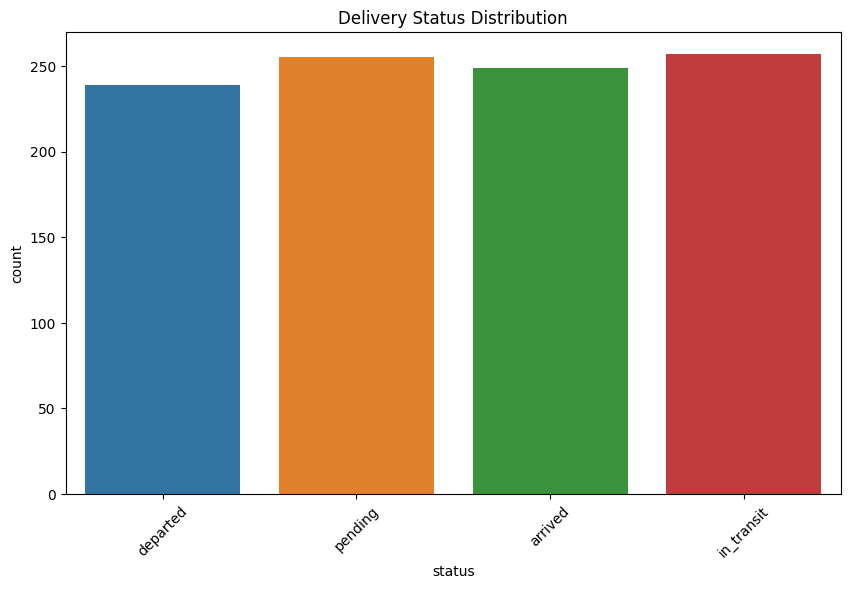

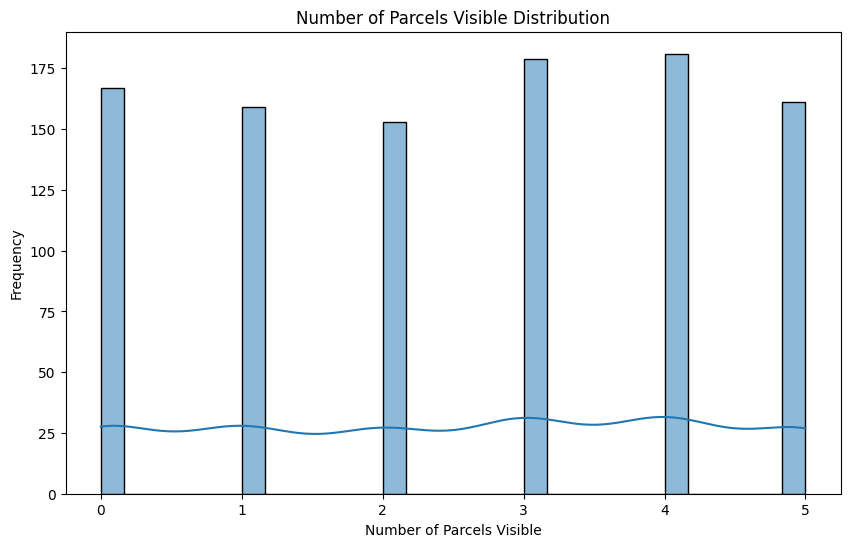

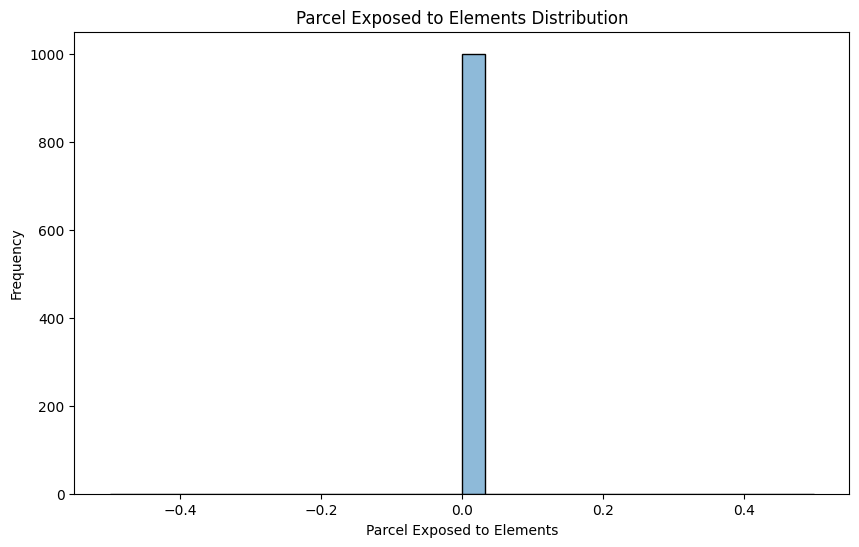

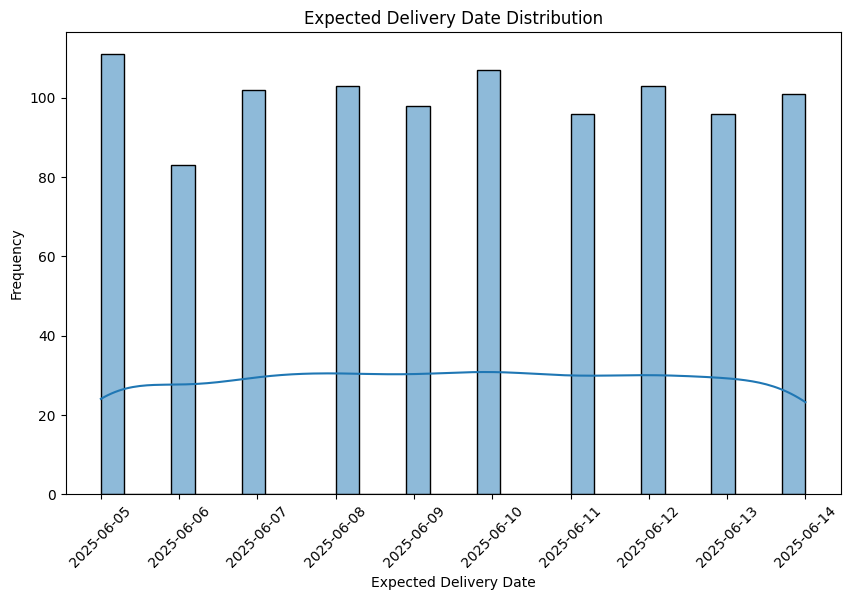

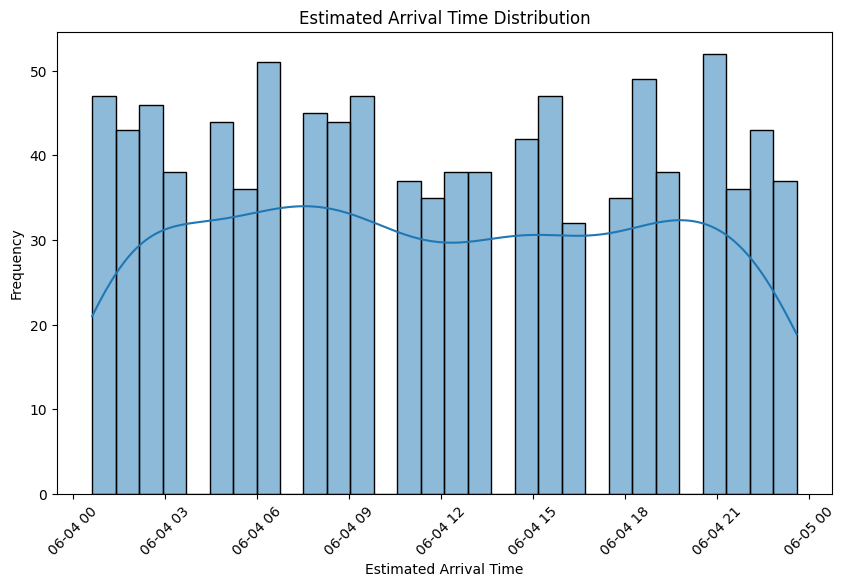

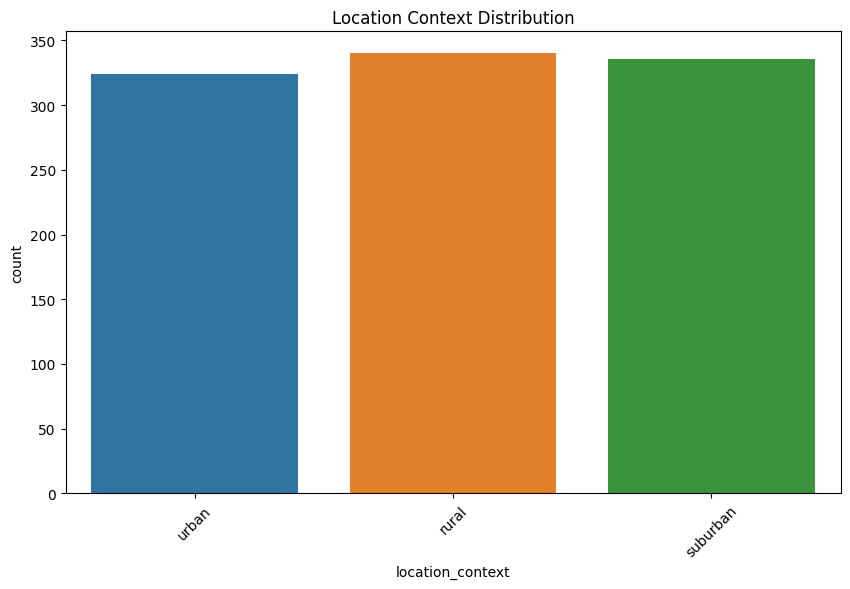

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the data into a Pandas DataFrame for visualization
df = spark.table("silver_delivery").toPandas()

# Check if the DataFrame is empty after loading
if df.empty:
    print("The DataFrame is empty after loading from the Spark table.")
else:
    # Convert necessary columns to numeric or datetime
    df['expected_delivery_date'] = pd.to_datetime(df['expected_delivery_date'], errors='coerce')
    df['estimated_arrival_time'] = pd.to_datetime(df['estimated_arrival_time'], errors='coerce')
    df['number_of_parcels_visible'] = pd.to_numeric(df['number_of_parcels_visible'], errors='coerce')
    df['parcel_exposed_to_elements'] = pd.to_numeric(df['parcel_exposed_to_elements'], errors='coerce')

    # Replace NaN values with default values
    df['parcel_exposed_to_elements'] = df['parcel_exposed_to_elements'].fillna(0)
    df['number_of_parcels_visible'] = df['number_of_parcels_visible'].fillna(0)
    df['status'] = df['status'].fillna('Unknown')

    # 1. Delivery Status Distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='status')
    plt.title('Delivery Status Distribution')
    plt.xticks(rotation=45)
    plt.show()

    # 2. Number of Parcels Visible Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(df['number_of_parcels_visible'], bins=30, kde=True)
    plt.title('Number of Parcels Visible Distribution')
    plt.xlabel('Number of Parcels Visible')
    plt.ylabel('Frequency')
    plt.show()

    # 3. Parcel Exposed to Elements Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(df['parcel_exposed_to_elements'], bins=30, kde=True)
    plt.title('Parcel Exposed to Elements Distribution')
    plt.xlabel('Parcel Exposed to Elements')
    plt.ylabel('Frequency')
    plt.show()

    # 4. Expected Delivery Date Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(df['expected_delivery_date'].dropna(), bins=30, kde=True)
    plt.title('Expected Delivery Date Distribution')
    plt.xlabel('Expected Delivery Date')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()

    # 5. Estimated Arrival Time Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(df['estimated_arrival_time'].dropna(), bins=30, kde=True)
    plt.title('Estimated Arrival Time Distribution')
    plt.xlabel('Estimated Arrival Time')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()

    # 6. Location Context Distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='location_context')
    plt.title('Location Context Distribution')
    plt.xticks(rotation=45)
    plt.show()

### My experiments

In [0]:
bucket_path = "s3a://sppevribucket/"
files = dbutils.fs.ls(bucket_path)
print(len(files))
display(files)

13


path,name,size,modificationTime
s3a://sppevribucket/H10000 - Copy.json,H10000 - Copy.json,276,1748685202000
s3a://sppevribucket/H10000.json,H10000.json,276,1748685202000
s3a://sppevribucket/H10001 - Copy.json,H10001 - Copy.json,277,1748685201000
s3a://sppevribucket/H10001.json,H10001.json,277,1748685201000
s3a://sppevribucket/H10002 - Copy (2).json,H10002 - Copy (2).json,242,1748685199000
s3a://sppevribucket/H10002 - Copy - Copy.json,H10002 - Copy - Copy.json,242,1748685199000
s3a://sppevribucket/H10002 - Copy.json,H10002 - Copy.json,242,1748685200000
s3a://sppevribucket/H10002.json,H10002.json,242,1748685200000
s3a://sppevribucket/H10003.json,H10003.json,270,1748687269000
s3a://sppevribucket/2025_5_31/,2025_5_31/,0,1748965351877


In [0]:
from pyspark.sql.functions import input_file_name

# Define your S3 path
bucket_path = "s3a://sppevribucket/"

# Read only H1*.json files (ignoring copies and directories)
df = (spark.read
      .format("json")
      .option("pathGlob", "H*.json")  # Matches files starting with H1 and ending with .json
      .option("recursiveFileLookup", "true")  # Searches subdirectories
      .load(bucket_path))

# Add source file information
df = df.withColumn("source_file", input_file_name())

# Show results
print(f"Read {df.count()} records from matching files")
display(df)

Read 1047 records from matching files


_corrupt_record,address,age,city,company,company1,email,employee_id,employee_name,is_active,name,position,skills_primary,source_file
null,null,65,New York,null,null,null,null,null,null,Bob Brown,null,null,s3a://sppevribucket/sample1/part-00000-tid-739645513121545470-0eaa54b0-dadf-4f12-ae64-8f78b2a7f1d9-18-1-c000.json
null,null,21,New York,null,null,null,null,null,null,Bob Brown,null,null,s3a://sppevribucket/sample1/part-00000-tid-739645513121545470-0eaa54b0-dadf-4f12-ae64-8f78b2a7f1d9-18-1-c000.json
null,null,61,New York,null,null,null,null,null,null,John Doe,null,null,s3a://sppevribucket/sample1/part-00000-tid-739645513121545470-0eaa54b0-dadf-4f12-ae64-8f78b2a7f1d9-18-1-c000.json
null,null,48,Chicago,null,null,null,null,null,null,Bob Brown,null,null,s3a://sppevribucket/sample1/part-00000-tid-739645513121545470-0eaa54b0-dadf-4f12-ae64-8f78b2a7f1d9-18-1-c000.json
null,null,49,New York,null,null,null,null,null,null,John Doe,null,null,s3a://sppevribucket/sample1/part-00000-tid-739645513121545470-0eaa54b0-dadf-4f12-ae64-8f78b2a7f1d9-18-1-c000.json
null,null,30,Chicago,null,null,null,null,null,null,John Doe,null,null,s3a://sppevribucket/sample1/part-00000-tid-739645513121545470-0eaa54b0-dadf-4f12-ae64-8f78b2a7f1d9-18-1-c000.json
null,null,57,Houston,null,null,null,null,null,null,Jane Smith,null,null,s3a://sppevribucket/sample1/part-00000-tid-739645513121545470-0eaa54b0-dadf-4f12-ae64-8f78b2a7f1d9-18-1-c000.json
null,null,41,Houston,null,null,null,null,null,null,Bob Brown,null,null,s3a://sppevribucket/sample1/part-00000-tid-739645513121545470-0eaa54b0-dadf-4f12-ae64-8f78b2a7f1d9-18-1-c000.json
null,null,62,Los Angeles,null,null,null,null,null,null,Alice Johnson,null,null,s3a://sppevribucket/sample1/part-00000-tid-739645513121545470-0eaa54b0-dadf-4f12-ae64-8f78b2a7f1d9-18-1-c000.json
null,null,53,New York,null,null,null,null,null,null,Jane Smith,null,null,s3a://sppevribucket/sample1/part-00000-tid-739645513121545470-0eaa54b0-dadf-4f12-ae64-8f78b2a7f1d9-18-1-c000.json


In [0]:
# Define the path to the specific JSON file
file_path = f"s3a://sppevribucket/rawdata3/H00999.json"

# Read the JSON file into a DataFrame
df = spark.read.option("multiline", "true").json(file_path)

# Display the content of the DataFrame
display(df)


acceptable_image_quality,door_open,door_type,door_visible,location_context,number_of_parcels_visible,parcel_environment,parcel_exposed_to_elements,parcel_visible,pii_in_image,raw_features,resident_visible
true,yes,metal,yes,suburban,0,porch,yes,no,yes,some_raw_features_data,yes
